# Sales Performance Analysis — Target vs Achieved

In [1]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import random

sales_reps = ["Thabo", "Aisha", "Sipho", "Naledi", "Johan", "Zanele", "Pieter", "Lerato"]
products = ["Beverages", "Snacks", "Household", "Personal Care"]
regions = ("Western Cape", "Gauteng", "KwaZulu-Natal", "Eastern Cape")

n_records = 150

In [3]:
rep_list = []
region_list = []
product_list = []
target_list = []
achieved_list = []

for i in range(n_records):
    rep = random.choice(sales_reps)
    region = random.choice(regions)
    product = random.choice(products)

    target = random.randint(50000, 150000)      
    achieved = random.randint(30000, 180000)     

    rep_list.append(rep)
    region_list.append(region)
    product_list.append(product)
    target_list.append(target)
    achieved_list.append(achieved)

print("First 5 targets:", target_list[:5])
print("First 5 achieved:", achieved_list[:5])


First 5 targets: [91127, 84060, 146417, 135317, 120659]
First 5 achieved: [63208, 140575, 171576, 143848, 93039]


In [4]:
df = pd.DataFrame({
    "SalesRep": rep_list,
    "Region": region_list,
    "Product": product_list,
    "Target": target_list,
    "Achieved": achieved_list
})

df.head()

,SalesRep,Region,Product,Target,Achieved
0,Thabo,KwaZulu-Natal,Snacks,91127,63208
1,Naledi,Gauteng,Beverages,84060,140575
2,Lerato,Gauteng,Snacks,146417,171576
3,Zanele,Eastern Cape,Snacks,135317,143848
4,Naledi,KwaZulu-Natal,Beverages,120659,93039


## 3. Calculate % Achieved

In [5]:
df["PctAchieved"] = (df["Achieved"] / df["Target"]) * 100
df["PctAchieved"] = round(df["PctAchieved"], 2)
df.head()

,SalesRep,Region,Product,Target,Achieved,PctAchieved
0,Thabo,KwaZulu-Natal,Snacks,91127,63208,69.36
1,Naledi,Gauteng,Beverages,84060,140575,167.23
2,Lerato,Gauteng,Snacks,146417,171576,117.18
3,Zanele,Eastern Cape,Snacks,135317,143848,106.30
4,Naledi,KwaZulu-Natal,Beverages,120659,93039,77.11


## 4. Classify performance with `if / elif / else`

In [6]:
performance_tier = []  

for pct in df["PctAchieved"]:
    if pct >= 100:
        performance_tier.append("Excellent")
    elif pct >= 85:
        performance_tier.append("Good")
    elif pct >= 70:
        performance_tier.append("Average")
    else:
        performance_tier.append("Below Target")

df["PerformanceTier"] = performance_tier
df.head()


,SalesRep,Region,Product,Target,Achieved,PctAchieved,PerformanceTier
0,Thabo,KwaZulu-Natal,Snacks,91127,63208,69.36,Below Target
1,Naledi,Gauteng,Beverages,84060,140575,167.23,Excellent
2,Lerato,Gauteng,Snacks,146417,171576,117.18,Excellent
3,Zanele,Eastern Cape,Snacks,135317,143848,106.30,Excellent
4,Naledi,KwaZulu-Natal,Beverages,120659,93039,77.11,Average


In [7]:
def classify_performance(pct):
    if pct >= 100:
        return "Excellent"
    elif pct >= 85:
        return "Good"
    elif pct >= 70:
        return "Average"
    else:
        return "Below Target"

# Try it on a couple of values
print(classify_performance(105))
print(classify_performance(60))

Excellent
Below Target


## 5. Explore the data


In [8]:
print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")
df.info()


Rows: 150   Columns: 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SalesRep         150 non-null    object 
 1   Region           150 non-null    object 
 2   Product          150 non-null    object 
 3   Target           150 non-null    int64  
 4   Achieved         150 non-null    int64  
 5   PctAchieved      150 non-null    float64
 6   PerformanceTier  150 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.3+ KB


In [9]:
df.describe()

,Target,Achieved,PctAchieved
count,150.000000,150.000000,150.000000
mean,100275.313333,108082.406667,119.096467
std,28595.974006,44754.311993,66.382379
min,50258.000000,31164.000000,22.970000
25%,75940.750000,69627.000000,67.797500
50%,99331.500000,117721.500000,104.735000
75%,125535.250000,144700.250000,165.465000
max,149618.000000,179593.000000,347.390000


In [10]:
# overall average % achieved across the whole team
average_pct = np.mean(df["PctAchieved"])
print("Average % Achieved across all records:", round(average_pct, 2))


Average % Achieved across all records: 119.1


In [11]:
# Distribution of performance tiers
tier_counts = df["PerformanceTier"].value_counts().to_dict()
tier_counts

{'Excellent': 81, 'Below Target': 42, 'Average': 16, 'Good': 11}

## 6. Group & aggregate with pandas

In [12]:
region_summary = df.groupby("Region")[["Target", "Achieved"]].sum()
region_summary["PctAchieved"] = round(region_summary["Achieved"] / region_summary["Target"] * 100, 2)
region_summary = region_summary.sort_values("PctAchieved", ascending=False)
region_summary

,Target,Achieved,PctAchieved
Region,,,
Western Cape,2369184,2822923,119.15
Eastern Cape,4532654,4911097,108.35
KwaZulu-Natal,4084192,4271730,104.59
Gauteng,4055267,4206611,103.73


In [13]:
rep_summary = df.groupby("SalesRep")[["Target", "Achieved"]].sum()
rep_summary["PctAchieved"] = round(rep_summary["Achieved"] / rep_summary["Target"] * 100, 2)
rep_summary = rep_summary.sort_values("PctAchieved", ascending=False)
rep_summary

,Target,Achieved,PctAchieved
SalesRep,,,
Lerato,2584877,3137865,121.39
Johan,1768001,1984709,112.26
Zanele,2143620,2334270,108.89
Sipho,1568860,1696748,108.15
Pieter,1649061,1755337,106.44
Thabo,1673544,1734748,103.66
Naledi,2170247,2241207,103.27
Aisha,1483087,1327477,89.51


## 7. Visualizations with Seaborn

### 7.1 Target vs Achieved by Region

In [14]:
chart_rows = []

for region in region_summary.index:
    chart_rows.append((region, "Target", region_summary.loc[region, "Target"]))
    chart_rows.append((region, "Achieved", region_summary.loc[region, "Achieved"]))

region_chart_df = pd.DataFrame(chart_rows, columns=["Region", "Metric", "Amount"])
region_chart_df.head()

,Region,Metric,Amount
0,Western Cape,Target,2369184
1,Western Cape,Achieved,2822923
2,Eastern Cape,Target,4532654
3,Eastern Cape,Achieved,4911097
4,KwaZulu-Natal,Target,4084192


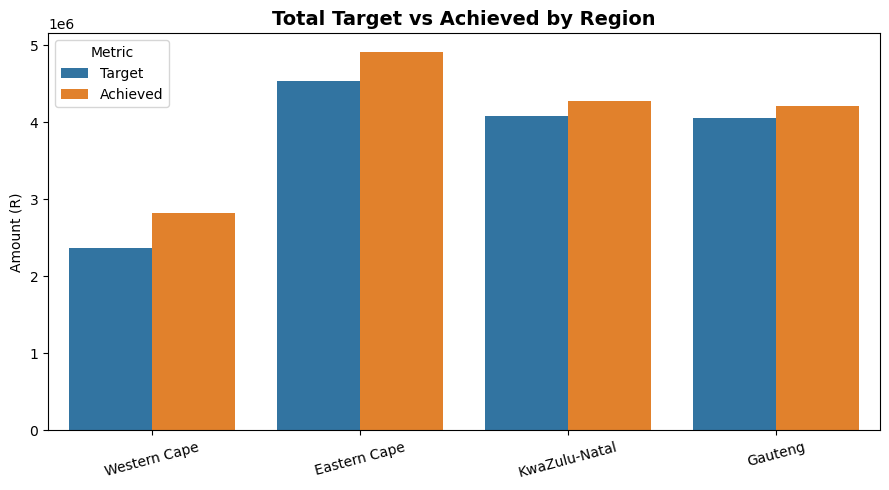

In [15]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=region_chart_df, x="Region", y="Amount", hue="Metric")
ax.set_title("Total Target vs Achieved by Region", fontsize=14, fontweight="bold")
ax.set_ylabel("Amount (R)")
ax.set_xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 7.2 % Achieved by Sales Rep

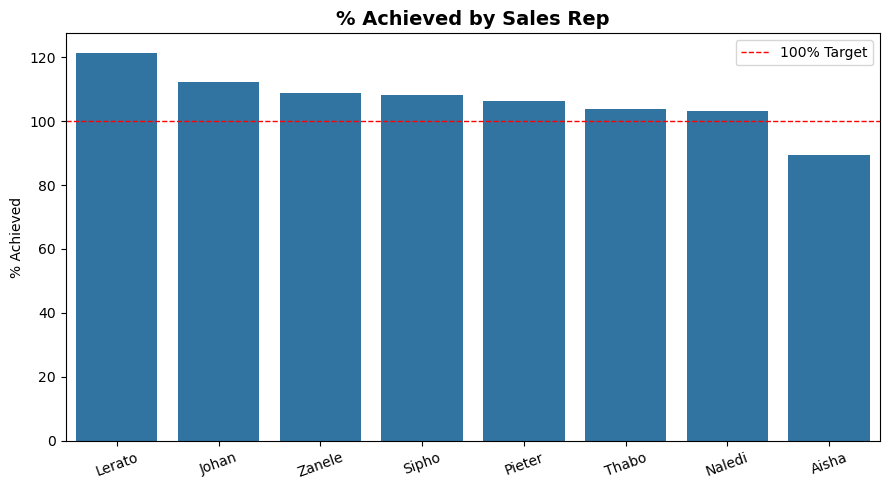

In [16]:
plt.figure(figsize=(9, 5))
order = rep_summary.index
ax = sns.barplot(x=rep_summary.index, y=rep_summary["PctAchieved"], order=order)

# Reference line at 100% target
ax.axhline(100, color="red", linestyle="--", linewidth=1, label="100% Target")

ax.set_title("% Achieved by Sales Rep", fontsize=14, fontweight="bold")
ax.set_ylabel("% Achieved")
ax.set_xlabel("")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

### 7.3 Performance Tier Distribution

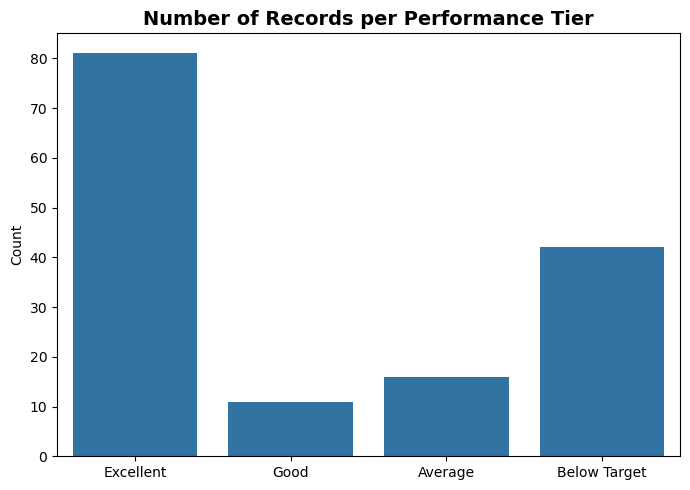

In [17]:
plt.figure(figsize=(7, 5))
tier_order = ["Excellent", "Good", "Average", "Below Target"]
ax = sns.countplot(data=df, x="PerformanceTier", order=tier_order)
ax.set_title("Number of Records per Performance Tier", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 7.4 Spread of % Achieved by Product

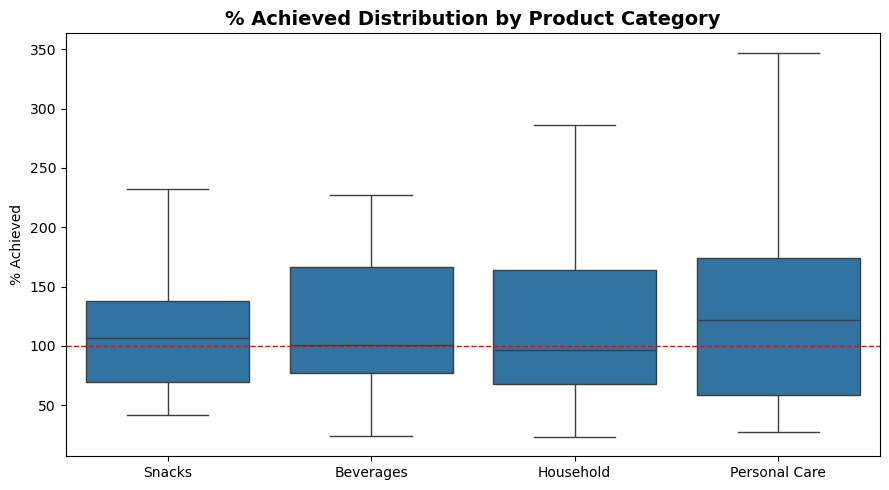

In [18]:
plt.figure(figsize=(9, 5))
ax = sns.boxplot(data=df, x="Product", y="PctAchieved")
ax.axhline(100, color="red", linestyle="--", linewidth=1)
ax.set_title("% Achieved Distribution by Product Category", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("% Achieved")
plt.tight_layout()
plt.show()

### 7.5 Correlation Heatmap

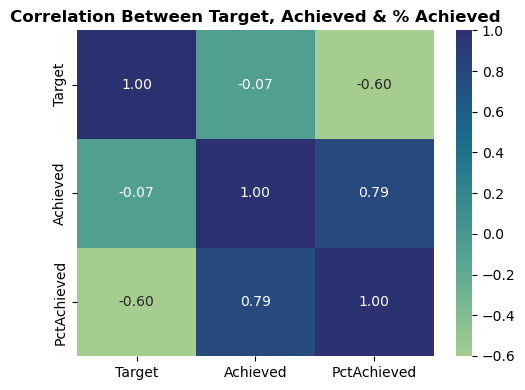

In [19]:
plt.figure(figsize=(5, 4))
corr = df[["Target", "Achieved", "PctAchieved"]].corr()
sns.heatmap(corr, annot=True, cmap="crest", fmt=".2f")
plt.title("Correlation Between Target, Achieved & % Achieved", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()